# Solving the 1D Transient Heat Equation with finite difference method

This notebook solves the 1D transient heat equation using implicit finite difference method with the following setup:

- **Domain**: $\Omega = [0, 1] \text{ and } t = [0, 1]$
- **Boundary Conditions**: $u(x = 0, t) = u(x = 1, t) = 0$
- **Initial Conditions**: $u(x, t = 0) = \sin(\pi x)$
- **Analytical Solution**: $u_{\text{analytical}} = e^{-\alpha \pi^2 t} \sin(\pi x)$

1. Import necessary libraries

In [9]:
import numpy as np
import matplotlib.pyplot as plt # For plotting
from scipy.linalg import solve  # For solving linear systems

2. Define the parameters

In [ ]:
L = 1.0           # Length of the domain
T = 1.0           # Total simulation time
alpha = 0.1       # Thermal diffusivity
Nx_initial = 100  # Initial number of spatial grid points
Nt_initial = 100  # Initial number of time steps

3. Define the analytical solution

In [11]:
def analytical_solution(x, t, alpha):
    return np.exp(-alpha * np.pi**2 * t) * np.sin(np.pi * x)

4. Define the L2 error in space and time

In [12]:
# Function to calculate the L2 error for spatial convergence at a single time step
def calculate_L2_error_spatial(u_numerical, u_analytical, dx):
    return np.sqrt(np.sum((u_numerical - u_analytical) ** 2) * dx)

# Function to calculate the L2 error for temporal convergence over the entire time domain
def calculate_L2_error_temporal(u_numerical, u_analytical, dt):
    # Sum the error across all time steps and spatial points
    return np.sqrt(np.sum((u_numerical - u_analytical) ** 2) * dt)

5. Solve the equation using Backward Euler method

In [ ]:
def solve_heat_equation_implicit(Nx, Nt):
    dx = L / (Nx - 1)       # Spatial step size
    dt = T / Nt             # Time step size
    r = alpha * dt / dx**2  # Stability parameter

    x = np.linspace(0, L, Nx)           # Spatial grid
    u = np.zeros((Nt, Nx))              # Numerical solution array, first index is time, second is space
    # Calculate analytical solution array on the same grid as numerical solution for error calculation
    u_analytical = np.zeros((Nt, Nx))

    # IC & BCs
    u[0, :] = np.sin(np.pi * x)     # Set initial temperature profile
    u[:, 0] = 0                     # Boundary condition at x = 0
    u[:, -1] = 0                    # Boundary condition at x = L

    # Construct the tridiagonal matrix A for the Backward Euler scheme
    A = np.zeros((Nx - 2, Nx - 2))

    for i in range(1, Nx - 1):
        if i > 1:
            A[i - 1, i - 2] = -r
        A[i - 1, i - 1] = 1 + 2 * r
        if i < Nx - 2:
            A[i - 1, i] = -r

    # Time-stepping loop using Backward Euler
    for n in range(0, Nt - 1):
        b = u[n, 1:-1]  # Right-hand side is purely the previous time step
        u[n + 1, 1:-1] = solve(A, b)

    # Compute the analytical solution at each time step
    for n in range(Nt):
        t = n * dt
        u_analytical[n, :] = analytical_solution(x, t, alpha)

    # Calculate L2 error at the final time step for spatial convergence over the spatial domain
    L2_error_spatial = calculate_L2_error_spatial(u[-1, :], u_analytical[-1, :], dx)

    # Calculate L2 error for temporal convergence over the whole time domain
    L2_error_temporal = calculate_L2_error_temporal(u[:, :], u_analytical[:, :], dt)

    return u, u_analytical, L2_error_spatial, L2_error_temporal, dx, dt

# Initial run with initial parameters
u, u_analytical, _, _, dx_initial, dt_initial = solve_heat_equation_implicit(Nx_initial, Nt_initial)

# Run analytical solution at finer resolution for plotting
u_true = np.zeros((Nt_initial, 1000))
x_true = np.linspace(0, L, 1000)
for n in range(Nt_initial):
    t = n * dt_initial
    u_true[n, :] = analytical_solution(x_true, t, alpha)

6. Plot the results

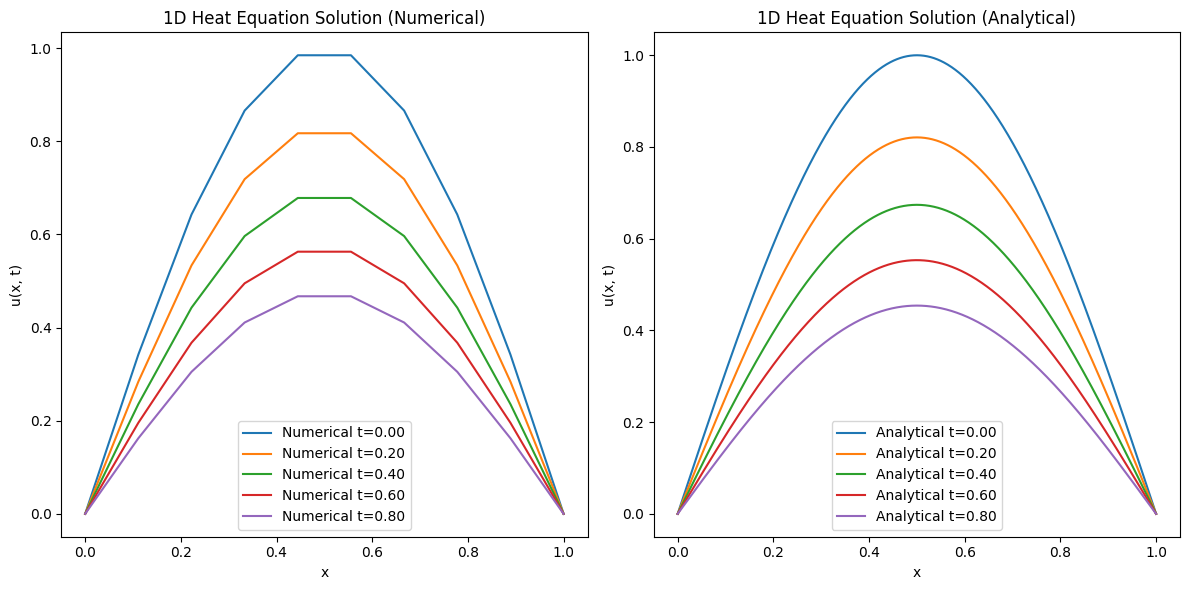

In [14]:
# Plot the numerical and analytical solutions
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
for n in range(0, Nt_initial, Nt_initial // 5):
    plt.plot(np.linspace(0, L, Nx_initial), u[n, :], label=f'Numerical t={n * dt_initial:.2f}')
plt.xlabel('x')
plt.ylabel('u(x, t)')
plt.title('1D Heat Equation Solution (Numerical)')
plt.legend()

plt.subplot(1, 2, 2)
for n in range(0, Nt_initial, Nt_initial // 5):
    plt.plot(np.linspace(0, L, 1000), u_true[n, :], label=f'Analytical t={n * dt_initial:.2f}')
plt.xlabel('x')
plt.ylabel('u(x, t)')
plt.title('1D Heat Equation Solution (Analytical)')
plt.legend()

plt.tight_layout()
plt.show()

7. Spatial convergence

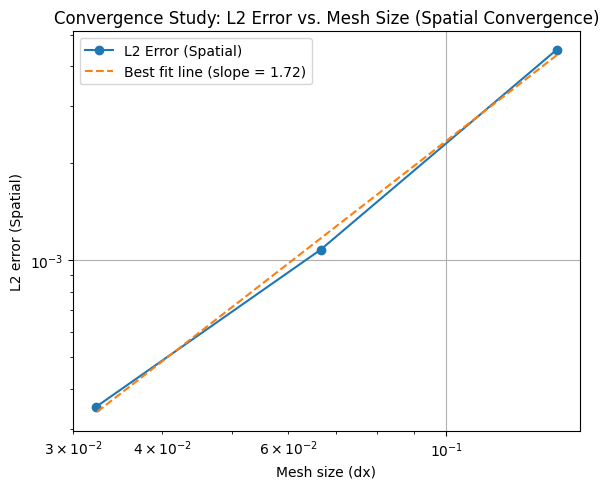

Slope for spatial convergence (expected ~2): 1.72


In [15]:
# Spatial convergence study: Varying mesh size Nx
Nx_values = [8, 16, 32]
Nt_fixed = 1000  # Keep the number of time steps fixed
L2_errors_mesh = []
dx_values = []

for Nx in Nx_values:
    _, _, L2_error_spatial, _, dx, _ = solve_heat_equation_implicit(Nx, Nt_fixed)
    L2_errors_mesh.append(L2_error_spatial)
    dx_values.append(dx)

# Plotting spatial convergence (log-log scale)
plt.figure(figsize=(6, 5))
plt.loglog(dx_values, L2_errors_mesh, '-o', label='L2 Error (Spatial)')
slope_mesh, intercept_mesh = np.polyfit(np.log(dx_values), np.log(L2_errors_mesh), 1)
plt.loglog(dx_values, np.exp(intercept_mesh) * np.array(dx_values)**slope_mesh, '--', label=f'Best fit line (slope = {slope_mesh:.2f})')

plt.xlabel('Mesh size (dx)')
plt.ylabel('L2 error (Spatial)')
plt.title('Convergence Study: L2 Error vs. Mesh Size (Spatial Convergence)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# Output the slopes to verify correctness
print(f"Slope for spatial convergence (expected ~2): {slope_mesh:.2f}")

8. Temporal convergence

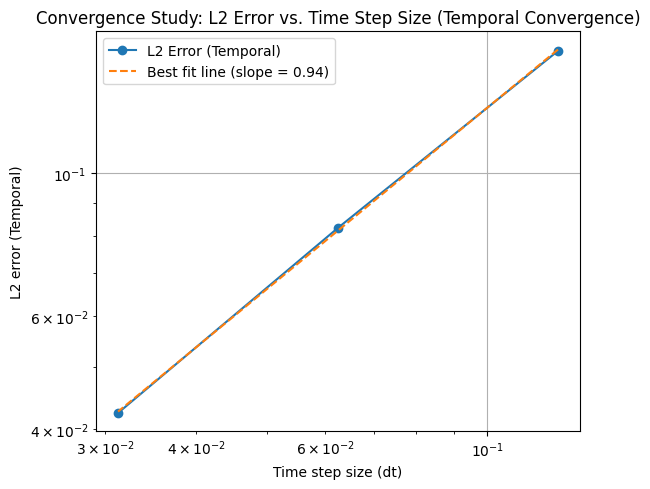

Slope for time convergence (expected ~1): 0.94


In [16]:
# Temporal convergence study: Varying number of time steps (Nt)
Nt_values = [8, 16, 32]

Nx_fixed = 200  # Keep the number of spatial points fixed
L2_errors_time = []
dt_values = []

for Nt in Nt_values:
    _, _, _, L2_error_temporal, _, dt = solve_heat_equation_implicit(Nx_fixed, Nt)
    L2_errors_time.append(L2_error_temporal)
    dt_values.append(dt)

# Plotting temporal convergence (log-log scale)
plt.figure(figsize=(6, 5))
plt.loglog(dt_values, L2_errors_time, '-o', label='L2 Error (Temporal)')
slope_time, intercept_time = np.polyfit(np.log(dt_values), np.log(L2_errors_time), 1)
plt.loglog(dt_values, np.exp(intercept_time) * np.array(dt_values)**slope_time, '--', label=f'Best fit line (slope = {slope_time:.2f})')

plt.xlabel('Time step size (dt)')
plt.ylabel('L2 error (Temporal)')
plt.title('Convergence Study: L2 Error vs. Time Step Size (Temporal Convergence)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# Output the slopes to verify correctness
print(f"Slope for time convergence (expected ~1): {slope_time:.2f}")